In [1]:
import sys
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), Path.cwd().parent] if (p / "src").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# NOTE (Windows): import pandas / src.data BEFORE torch. Importing torch first
# loads DLLs that make pyarrow's import fault, crashing the kernel under the debugger.
import numpy as np
from src.data import load_features, load_raw_signals, load_activity_map   # imports pandas
import torch                                                              # safe now

np.random.seed(42)
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

id_to_activity = load_activity_map()
class_names = [id_to_activity[i] for i in range(1, 7)]

X_train, y_train, subj_train = load_features("train")
X_test,  y_test,  subj_test  = load_features("test")
Xtr_raw = load_raw_signals("train")
Xte_raw = load_raw_signals("test")

print("Features:", X_train.shape, X_test.shape, "| Raw:", Xtr_raw.shape, Xte_raw.shape)
print("Device:", device)

Features: (7352, 561) (2947, 561) | Raw: (7352, 128, 9) (2947, 128, 9)
Device: cuda


In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.metrics import accuracy_score, f1_score

# Small, sensible grid. CV is subject-wise (GroupKFold on subject id) and uses ONLY
# the training subjects — the test set stays untouched.
param_grid = {
    "n_estimators": [300, 600],
    "max_depth":    [None, 30],
    "max_features": ["sqrt", 0.2],
}
gkf  = GroupKFold(n_splits=5)
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=gkf, scoring="f1_macro", n_jobs=-1, verbose=1,
)
grid.fit(X_train, y_train, groups=subj_train)      # groups => subject-wise folds

print("\nBest params:", grid.best_params_)
print(f"Best CV macro-F1 (training subjects): {grid.best_score_:.4f}")

best_rf = grid.best_estimator_
rf_pred = best_rf.predict(X_test)
print(f"\nTuned RF  -> test accuracy: {accuracy_score(y_test, rf_pred):.4f} "
      f"| macro-F1: {f1_score(y_test, rf_pred, average='macro'):.4f}")
print("v1 default RF -> test accuracy: 0.9287 | macro-F1: 0.927")

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best params: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 600}
Best CV macro-F1 (training subjects): 0.9175

Tuned RF  -> test accuracy: 0.9264 | macro-F1: 0.9243
v1 default RF -> test accuracy: 0.9287 | macro-F1: 0.927


In [3]:
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Standardize raw signals with TRAIN stats only (no leakage)
ch_mean = Xtr_raw.mean(axis=(0, 1))
ch_std  = Xtr_raw.std(axis=(0, 1))
Xtr_std = (Xtr_raw - ch_mean) / ch_std
Xte_std = (Xte_raw - ch_mean) / ch_std

ytr = y_train - 1     # 0..5 for CrossEntropyLoss
yte = y_test - 1

# Subject-wise validation split: hold out 4 training subjects for tuning
val_subjects = [27, 28, 29, 30]
val_mask = np.isin(subj_train, val_subjects)
fit_mask = ~val_mask

def make_loader(X, y, bs=64, shuffle=False):
    Xt = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1)   # (n,9,128)
    yt = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(Xt, yt), batch_size=bs, shuffle=shuffle)

fit_loader  = make_loader(Xtr_std[fit_mask], ytr[fit_mask], shuffle=True)
val_loader  = make_loader(Xtr_std[val_mask], ytr[val_mask])
full_loader = make_loader(Xtr_std, ytr, shuffle=True)   # all 21 subjects (final retrain)
test_loader = make_loader(Xte_std, yte)

print("fit:", int(fit_mask.sum()), "| val:", int(val_mask.sum()),
      "| full-train:", len(ytr), "| test:", len(yte))

fit: 5867 | val: 1485 | full-train: 7352 | test: 2947


In [4]:
from copy import deepcopy
import torch.nn.functional as F
from sklearn.metrics import f1_score, accuracy_score
from src.model import HAR_CNN

def predict_loader(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            preds.append(model(xb.to(device)).argmax(1).cpu().numpy())
            trues.append(yb.numpy())
    return np.concatenate(preds), np.concatenate(trues)

def macro_f1_on(model, loader):
    p, t = predict_loader(model, loader)
    return f1_score(t, p, average="macro")

def train_model(train_loader, val_loader=None, lr=1e-3, dropout=0.3, epochs=30):
    """Train a CNN. If val_loader is given, keep the best-validation-macro-F1 epoch."""
    model = HAR_CNN(dropout=dropout).to(device)
    crit = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    best_f1, best_state = -1.0, None
    for _ in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            crit(model(xb), yb).backward()
            opt.step()
        if val_loader is not None:
            vf1 = macro_f1_on(model, val_loader)
            if vf1 > best_f1:
                best_f1, best_state = vf1, deepcopy(model.state_dict())
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_f1

In [5]:
configs = [(1e-3, 0.3), (1e-3, 0.5), (5e-4, 0.3), (5e-4, 0.5)]

best = None
for lr, dp in configs:
    torch.manual_seed(42)
    m, vf1 = train_model(fit_loader, val_loader, lr=lr, dropout=dp, epochs=30)
    print(f"lr={lr:<6} dropout={dp} -> validation macro-F1 {vf1:.4f}")
    if best is None or vf1 > best[2]:
        best = (lr, dp, vf1, m)

best_lr, best_dp, best_vf1, best_cnn = best
print(f"\nBest config: lr={best_lr}, dropout={best_dp}  (val macro-F1 {best_vf1:.4f})")

# Test evaluation of the tuned CNN (best config, best-val checkpoint)
cnn_pred, _ = predict_loader(best_cnn, test_loader)
cnn_pred = cnn_pred + 1
print(f"\nTuned CNN -> test accuracy {accuracy_score(y_test, cnn_pred):.4f} "
      f"| macro-F1 {f1_score(y_test, cnn_pred, average='macro'):.4f}")
print("v1 CNN    -> test accuracy 0.9335 | macro-F1 0.934")

lr=0.001  dropout=0.3 -> validation macro-F1 0.9451
lr=0.001  dropout=0.5 -> validation macro-F1 0.9439
lr=0.0005 dropout=0.3 -> validation macro-F1 0.9457
lr=0.0005 dropout=0.5 -> validation macro-F1 0.9464

Best config: lr=0.0005, dropout=0.5  (val macro-F1 0.9464)

Tuned CNN -> test accuracy 0.9450 | macro-F1 0.9449
v1 CNN    -> test accuracy 0.9335 | macro-F1 0.934


In [ ]:
import importlib, src.model
importlib.reload(src.model)                     # pick up the newly-added HAR_LSTM
from src.model import HAR_CNN, HAR_LSTM

def train_generic(model, train_loader, val_loader=None, lr=1e-3, epochs=30):
    """Train any model that consumes (batch, 9, 128); keep best-val-macro-F1 epoch."""
    model = model.to(device)
    crit = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    best_f1, best_state = -1.0, None
    for _ in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            crit(model(xb), yb).backward()
            opt.step()
        if val_loader is not None:
            vf1 = macro_f1_on(model, val_loader)
            if vf1 > best_f1:
                best_f1, best_state = vf1, deepcopy(model.state_dict())
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_f1

torch.manual_seed(42)
lstm_model, lstm_vf1 = train_generic(HAR_LSTM(dropout=0.5), fit_loader, val_loader,
                                     lr=5e-4, epochs=30)
print(f"LSTM validation macro-F1: {lstm_vf1:.4f}")

lstm_pred, _ = predict_loader(lstm_model, test_loader)
lstm_pred = lstm_pred + 1
print(f"\nLSTM       -> test accuracy {accuracy_score(y_test, lstm_pred):.4f} "
      f"| macro-F1 {f1_score(y_test, lstm_pred, average='macro'):.4f}")
print("Tuned CNN  -> test accuracy 0.9450 | macro-F1 0.9449")
print("Tuned RF   -> test accuracy 0.9264 | macro-F1 0.9243")

LSTM validation macro-F1: 0.9488

LSTM       -> test accuracy 0.8945 | macro-F1 0.8947
Tuned CNN  -> test accuracy 0.9450 | macro-F1 0.9449
Tuned RF   -> test accuracy 0.9264 | macro-F1 0.9243


In [8]:
import torch.nn.functional as F
from sklearn.ensemble import RandomForestClassifier

# RF trained on the SAME fit-subset as the CNN (val subjects 27-30 excluded) -> clean val
rf_fit = RandomForestClassifier(n_estimators=600, max_features="sqrt", random_state=42)
rf_fit.fit(X_train[fit_mask], y_train[fit_mask])

def proba_cnn(model, loader):
    model.eval()
    out = []
    with torch.no_grad():
        for xb, _ in loader:
            out.append(F.softmax(model(xb.to(device)), dim=1).cpu().numpy())
    return np.concatenate(out)

# Probability tables (columns already aligned: index 0 -> class 1, ... 5 -> class 6)
rf_val,  rf_te  = rf_fit.predict_proba(X_train[val_mask]), rf_fit.predict_proba(X_test)
cnn_val, cnn_te = proba_cnn(best_cnn, val_loader), proba_cnn(best_cnn, test_loader)
yval = y_train[val_mask]

# Sweep the RF weight w:  ensemble = w*RF + (1-w)*CNN, choose best on VALIDATION
ws = np.linspace(0, 1, 21)
val_f1 = [f1_score(yval, (w*rf_val + (1-w)*cnn_val).argmax(1) + 1, average="macro") for w in ws]
best_w = ws[int(np.argmax(val_f1))]
print(f"Best RF weight (validation): {best_w:.2f}  | val macro-F1 {max(val_f1):.4f}")

# Apply the chosen weight to the untouched TEST set
def report(name, proba):
    pred = proba.argmax(1) + 1
    print(f"{name:<26} test acc {accuracy_score(y_test, pred):.4f} "
          f"| macro-F1 {f1_score(y_test, pred, average='macro'):.4f}")

report(f"Weighted ens (w={best_w:.2f})", best_w*rf_te + (1-best_w)*cnn_te)
report("Equal 50/50 ensemble",          0.5*rf_te + 0.5*cnn_te)
report("Tuned CNN alone",               cnn_te)

Best RF weight (validation): 1.00  | val macro-F1 0.9552
Weighted ens (w=1.00)      test acc 0.9192 | macro-F1 0.9174
Equal 50/50 ensemble       test acc 0.9484 | macro-F1 0.9483
Tuned CNN alone            test acc 0.9450 | macro-F1 0.9449


In [9]:
# Pool all 30 subjects
subjects_all = np.concatenate([subj_train, subj_test])
X_feat_all   = np.vstack([X_train, X_test])
y_all        = np.concatenate([y_train, y_test])
raw_all      = np.vstack([Xtr_raw, Xte_raw])
uniq_subjects = np.unique(subjects_all)

rf_accs, cnn_accs, lstm_accs = [], [], []

for subj in uniq_subjects:
    te = subjects_all == subj      # the one held-out person
    tr = ~te                       # the other 29

    # --- RF (on features) ---
    rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
    rf.fit(X_feat_all[tr], y_all[tr])
    rf_accs.append(accuracy_score(y_all[te], rf.predict(X_feat_all[te])))

    # --- Deep models (on raw signals, standardized with TRAIN stats of this fold) ---
    m, s = raw_all[tr].mean(axis=(0, 1)), raw_all[tr].std(axis=(0, 1))
    tl = make_loader((raw_all[tr] - m) / s, y_all[tr] - 1, shuffle=True)
    el = make_loader((raw_all[te] - m) / s, y_all[te] - 1)

    torch.manual_seed(42)
    cnn, _ = train_generic(HAR_CNN(dropout=0.5), tl, lr=5e-4, epochs=15)
    cp, _ = predict_loader(cnn, el)
    cnn_accs.append(accuracy_score(y_all[te] - 1, cp))

    torch.manual_seed(42)
    lstm, _ = train_generic(HAR_LSTM(dropout=0.5), tl, lr=5e-4, epochs=15)
    lp, _ = predict_loader(lstm, el)
    lstm_accs.append(accuracy_score(y_all[te] - 1, lp))

    print(f"subject {subj:2d} | RF {rf_accs[-1]:.3f} | CNN {cnn_accs[-1]:.3f} | LSTM {lstm_accs[-1]:.3f}")

print("\n=== Leave-One-Subject-Out results (mean ± std over 30 people) ===")
for name, accs in [("Random Forest", rf_accs), ("CNN", cnn_accs), ("LSTM", lstm_accs)]:
    a = np.array(accs)
    print(f"{name:<14} {a.mean():.4f} ± {a.std():.4f}   (worst subject: {a.min():.3f})")

subject  1 | RF 0.977 | CNN 1.000 | LSTM 1.000
subject  2 | RF 0.947 | CNN 0.901 | LSTM 0.887
subject  3 | RF 0.974 | CNN 1.000 | LSTM 0.988
subject  4 | RF 0.965 | CNN 0.959 | LSTM 0.899
subject  5 | RF 0.884 | CNN 0.864 | LSTM 0.831
subject  6 | RF 0.868 | CNN 0.960 | LSTM 0.975
subject  7 | RF 0.968 | CNN 0.951 | LSTM 0.968
subject  8 | RF 0.886 | CNN 0.922 | LSTM 0.890
subject  9 | RF 0.896 | CNN 0.910 | LSTM 0.760
subject 10 | RF 0.874 | CNN 0.741 | LSTM 0.670
subject 11 | RF 0.991 | CNN 1.000 | LSTM 0.851
subject 12 | RF 0.981 | CNN 0.997 | LSTM 1.000
subject 13 | RF 0.954 | CNN 1.000 | LSTM 0.994
subject 14 | RF 0.789 | CNN 0.728 | LSTM 0.765
subject 15 | RF 0.997 | CNN 1.000 | LSTM 1.000
subject 16 | RF 0.874 | CNN 0.770 | LSTM 0.658
subject 17 | RF 0.976 | CNN 0.924 | LSTM 0.913
subject 18 | RF 0.868 | CNN 0.975 | LSTM 0.981
subject 19 | RF 0.892 | CNN 0.989 | LSTM 0.947
subject 20 | RF 0.958 | CNN 1.000 | LSTM 0.938
subject 21 | RF 0.975 | CNN 0.985 | LSTM 0.833
subject 22 | 

Saved: C:\Users\abel\Documents\Python_projects\The HAR project\reports\figures\loso_boxplot.png


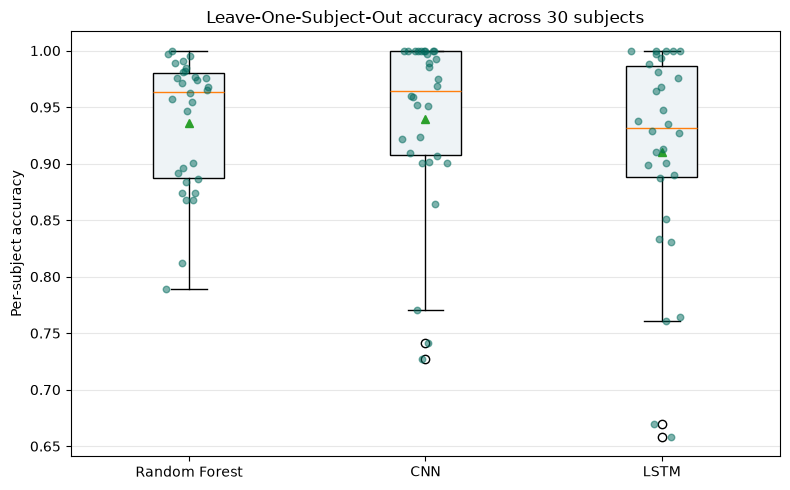

In [10]:
import matplotlib.pyplot as plt

data   = [rf_accs, cnn_accs, lstm_accs]
labels = ["Random Forest", "CNN", "LSTM"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(data, tick_labels=labels, showmeans=True, patch_artist=True,
           boxprops=dict(facecolor="#EEF3F6"))
for i, accs in enumerate(data, start=1):                 # overlay each subject
    x = np.random.normal(i, 0.05, size=len(accs))
    ax.scatter(x, accs, alpha=0.5, color="#00695C", s=22, zorder=3)
ax.set_ylabel("Per-subject accuracy")
ax.set_title("Leave-One-Subject-Out accuracy across 30 subjects")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

fig_dir = next(p for p in [Path("reports/figures"), Path("../reports/figures")] if p.exists())
fig.savefig(fig_dir / "loso_boxplot.png", dpi=150, bbox_inches="tight")
print("Saved:", (fig_dir / "loso_boxplot.png").resolve())
plt.show()

162 misclassified of 2947 (5.5%)

Most common errors (true -> predicted):
   63   SITTING -> STANDING
   49   STANDING -> SITTING
   24   WALKING_UPSTAIRS -> WALKING_DOWNSTAIRS
   21   SITTING -> WALKING_UPSTAIRS
    4   SITTING -> LAYING
    1   WALKING_UPSTAIRS -> WALKING

SITTING->STANDING errors: 63


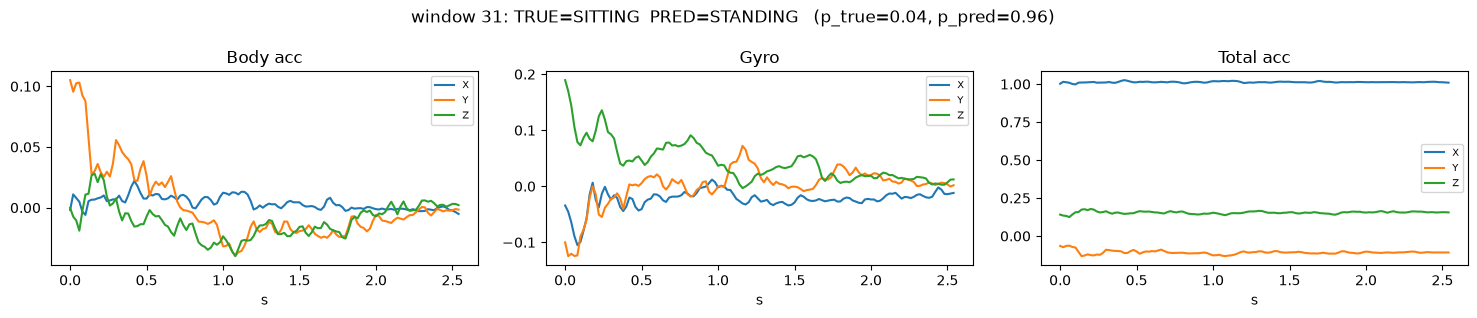

Cross-block (static<->moving) errors: 21


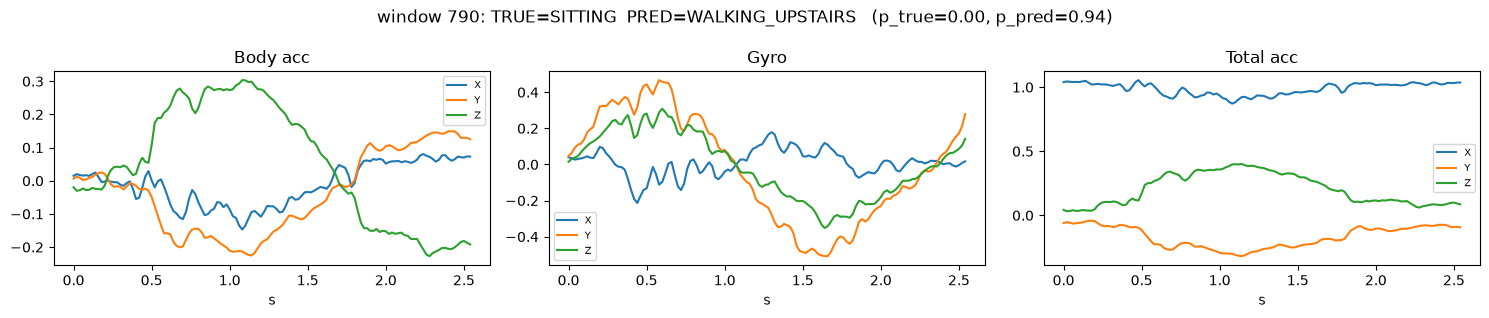

In [11]:
import collections
import matplotlib.pyplot as plt

cnn_pred = cnn_te.argmax(1) + 1                 # tuned CNN test predictions (from cell 7)
mis = np.where(cnn_pred != y_test)[0]
print(f"{len(mis)} misclassified of {len(y_test)} ({len(mis)/len(y_test):.1%})\n")

# Most common error types
conf = collections.Counter(
    (class_names[y_test[i] - 1], class_names[cnn_pred[i] - 1]) for i in mis)
print("Most common errors (true -> predicted):")
for (t, p), c in conf.most_common(6):
    print(f"  {c:3d}   {t} -> {p}")

def show_window(idx):
    """Plot the 9 raw channels of a window with true/pred labels and confidence."""
    t = np.arange(128) / 50.0
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.2))
    for ax, (title, st) in zip(axes, [("Body acc", 0), ("Gyro", 3), ("Total acc", 6)]):
        for j, a in enumerate("XYZ"):
            ax.plot(t, Xte_raw[idx, :, st + j], label=a)
        ax.set_title(title); ax.legend(fontsize=7); ax.set_xlabel("s")
    true, pred = class_names[y_test[idx] - 1], class_names[cnn_pred[idx] - 1]
    p = cnn_te[idx]
    fig.suptitle(f"window {idx}: TRUE={true}  PRED={pred}   "
                 f"(p_true={p[y_test[idx]-1]:.2f}, p_pred={p[cnn_pred[idx]-1]:.2f})",
                 fontsize=12)
    plt.tight_layout(); plt.show()

# Example 1: the dominant SITTING -> STANDING confusion
sit_as_stand = [i for i in mis if y_test[i] == 4 and cnn_pred[i] == 5]
print(f"\nSITTING->STANDING errors: {len(sit_as_stand)}")
if sit_as_stand:
    show_window(sit_as_stand[0])

# Example 2: a cross-block error (static <-> moving), if any
static, moving = {4, 5, 6}, {1, 2, 3}
cross = [i for i in mis if (y_test[i] in static) != (cnn_pred[i] in static)]
print(f"Cross-block (static<->moving) errors: {len(cross)}")
if cross:
    show_window(cross[0])

Saved: C:\Users\abel\Documents\Python_projects\The HAR project\reports\figures\error_analysis.png


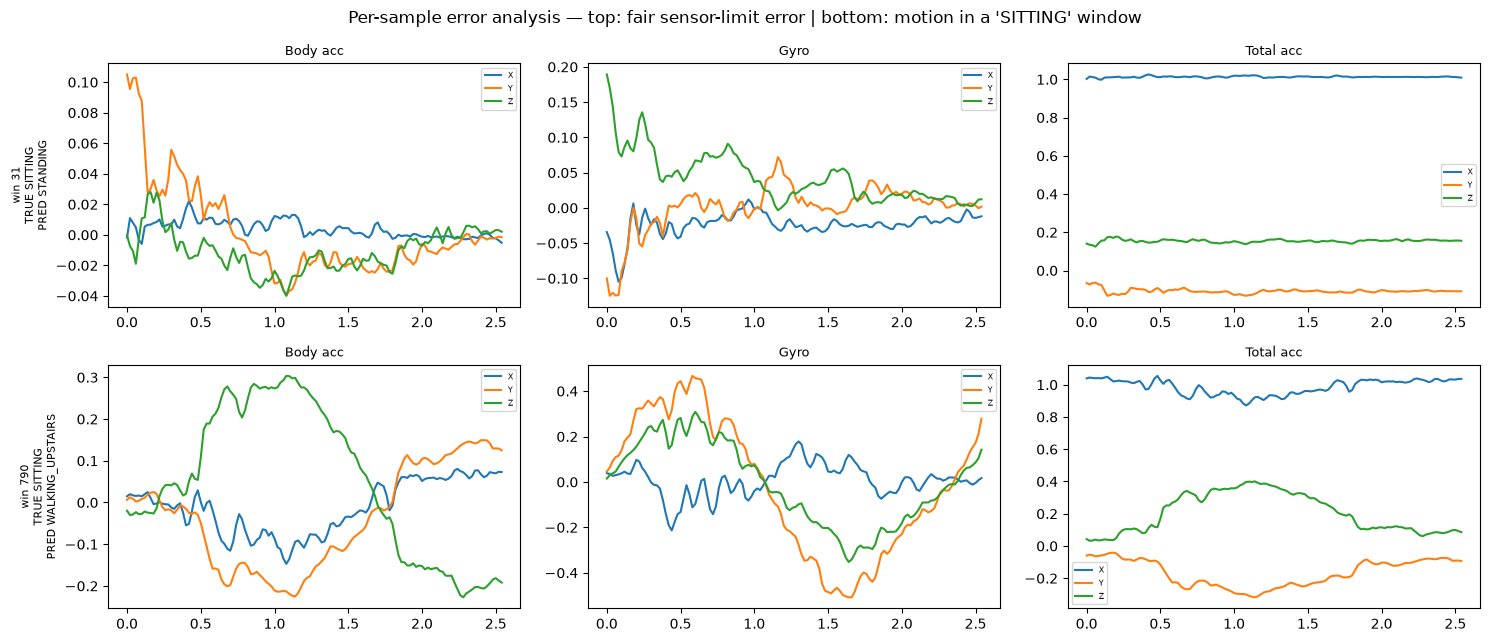

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 6.5))
examples = [(sit_as_stand[0], "Fair error: flat, upright — sensor can't resolve sit vs stand"),
            (cross[0],        "Data artifact: motion inside a 'SITTING' window (transition)")]
for row, (idx, _) in enumerate(examples):
    t = np.arange(128) / 50.0
    for ax, (title, st) in zip(axes[row], [("Body acc", 0), ("Gyro", 3), ("Total acc", 6)]):
        for j, a in enumerate("XYZ"):
            ax.plot(t, Xte_raw[idx, :, st + j], label=a)
        ax.set_title(title, fontsize=9); ax.legend(fontsize=6)
    axes[row][0].set_ylabel(f"win {idx}\nTRUE {class_names[y_test[idx]-1]}\nPRED {class_names[cnn_pred[idx]-1]}",
                            fontsize=8)
fig.suptitle("Per-sample error analysis — top: fair sensor-limit error | bottom: motion in a 'SITTING' window")
plt.tight_layout()
fig_dir = next(p for p in [Path("reports/figures"), Path("../reports/figures")] if p.exists())
fig.savefig(fig_dir / "error_analysis.png", dpi=150, bbox_inches="tight")
print("Saved:", (fig_dir / "error_analysis.png").resolve())
plt.show()

In [13]:
from scipy.stats import binomtest, wilcoxon

# Final test predictions for the three models (RF = tuned full-train best_rf)
rf_proba_full = best_rf.predict_proba(X_test)
rf_pred_full  = rf_proba_full.argmax(1) + 1
cnn_pred      = cnn_te.argmax(1) + 1
ens_proba     = 0.5 * rf_proba_full + 0.5 * cnn_te
ens_pred      = ens_proba.argmax(1) + 1

def bootstrap_ci(y_true, y_pred, n=2000):
    rng, N, s = np.random.default_rng(42), len(y_true), []
    for _ in range(n):
        idx = rng.integers(0, N, N)
        s.append(accuracy_score(y_true[idx], y_pred[idx]))
    return np.mean(s), np.percentile(s, 2.5), np.percentile(s, 97.5)

print("Bootstrap 95% CI for test accuracy (2000 resamples):")
for name, pred in [("RF", rf_pred_full), ("CNN", cnn_pred), ("Ensemble", ens_pred)]:
    m, lo, hi = bootstrap_ci(y_test, pred)
    print(f"  {name:<9} {m:.4f}  [{lo:.4f}, {hi:.4f}]")

# McNemar (paired, same test windows): CNN vs RF
cnn_ok, rf_ok = (cnn_pred == y_test), (rf_pred_full == y_test)
b = int(np.sum(cnn_ok & ~rf_ok))   # CNN right, RF wrong
c = int(np.sum(~cnn_ok & rf_ok))   # CNN wrong, RF right
p_mc = binomtest(min(b, c), b + c, 0.5).pvalue
print(f"\nMcNemar CNN vs RF (fixed split): CNN-only={b}, RF-only={c}, p={p_mc:.4f}")

# Wilcoxon signed-rank on LOSO per-subject accuracies (robust, all 30 people)
print("\nWilcoxon on LOSO per-subject accuracy:")
print(f"  CNN vs RF  : p={wilcoxon(cnn_accs, rf_accs).pvalue:.4f}")
print(f"  CNN vs LSTM: p={wilcoxon(cnn_accs, lstm_accs).pvalue:.4f}")

Bootstrap 95% CI for test accuracy (2000 resamples):
  RF        0.9265  [0.9169, 0.9359]
  CNN       0.9450  [0.9369, 0.9532]
  Ensemble  0.9481  [0.9399, 0.9559]

McNemar CNN vs RF (fixed split): CNN-only=136, RF-only=81, p=0.0002

Wilcoxon on LOSO per-subject accuracy:
  CNN vs RF  : p=0.6005
  CNN vs LSTM: p=0.0045
